In [ ]:
+!pip install transformers==3.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 4.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 769.0/769.0 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 40.3 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [46 lines of output]
      /tmp/pip-build-env-13pdm8eh/overlay/lib/python3.10/site-packages/setuptools/dist.py:330: InformationOnly: Normalizing '0.8.1.rc1' to '0.8.1rc1'
        self.metadata.version = self._normalize_version(self.metadata.version)
      running bdist_wheel
      running build
      running build_py
      creating build/lib.linux-x86_64-cpython-310/tokenizers
      copying tokenize

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import seaborn as sns
import transformers
import json
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaModel, RobertaTokenizer
import logging
logging.basicConfig(level=logging.ERROR)

from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'

In [ ]:
import pandas as pd

dataset_path = "/kaggle/input/experience-updated-upsampled-data/Experience updated upsampled_data.csv"


df = pd.read_csv(dataset_path)
df.head()


,Combined,Experience
0,"Name: Masum Rahman, Job_Title: Software Engine...",5
1,"Name: Majbah Uddin, Job_Title: Software Engine...",5
2,"Name: Mohammad Asif, Job_Title: Project Manage...",5
3,"Name: Robin Halder, Job_Title: Software Engine...",5
4,"Name: Masum Rahman, Job_Title: Software Engine...",5


In [ ]:
import re
import string

# Remove punctuations and unwanted characters
def strip_all_entities(text):
    text = text.replace('\r', '').replace('\n', ' ').lower()  # Remove \n and \r and lowercase
    text = re.sub(r"(?:\@|https?\://)\S+", "", text)
    text = re.sub(r'[^\x00-\x7f]', r'', text)  # Remove non-utf8/ascii characters
    banned_list = string.punctuation + 'Ã' + '±' + 'ã' + '¼' + 'â' + '»' + '§'
    table = str.maketrans('', '', banned_list)
    text = text.translate(table)
    return text

# Filter special characters such as & and $ present in some words
def filter_chars(a):
    sent = []
    for word in a.split(' '):
        if ('$' in word) | ('&' in word):
            sent.append('')
        else:
            sent.append(word)
    return ' '.join(sent)

# Remove multiple spaces
def remove_mult_spaces(text):
    return re.sub("\s\s+", " ", text)  # Replace multiple spaces with a single space

# Function to clean the raw text by applying all cleaning steps
def clean_text(text):
    text = strip_all_entities(text)
    text = filter_chars(text)
    text = remove_mult_spaces(text)
    return text

# Apply the clean_text function to the 'Combined' column and create a new 'CleanedText' column
df['CleanedText'] = df['Combined'].apply(clean_text)

# Display the first few rows of the DataFrame with the cleaned text
print(df[['Combined', 'CleanedText', 'Experience']].head())

df.to_csv('/kaggle/working/cleaned_data.csv', index=False)  # Replace with your desired file path

print("Cleaned text has been saved to 'cleaned_data.csv'.")


                                            Combined  \
0  Name: Masum Rahman, Job_Title: Software Engine...   
1  Name: Majbah Uddin, Job_Title: Software Engine...   
2  Name: Mohammad Asif, Job_Title: Project Manage...   
3  Name: Robin Halder, Job_Title: Software Engine...   
4  Name: Masum Rahman, Job_Title: Software Engine...   

                                         CleanedText  Experience  
0  name masum rahman jobtitle software engineer a...           5  
1  name majbah uddin jobtitle software engineer a...           5  
2  name mohammad asif jobtitle project manager at...           5  
3  name robin halder jobtitle software engineer 7...           5  
4  name masum rahman jobtitle software engineer a...           5  
Cleaned text has been saved to 'cleaned_data.csv'.


In [ ]:
# Apply the clean_text function to the 'Combined' column
df['CleanedText'] = df['Combined'].apply(clean_text)

# Create the labels based on Skills score
def map_labels(score):
    if score == 1 or score == 2:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral
    elif score == 4 or score == 5:
        return 2  # Positive

# Strip any leading or trailing spaces
df.columns = df.columns.str.strip()

# Apply the mapping function to the 'Experience' column
df['Experience_Label'] = df['Experience'].apply(map_labels)

print("Mapped Experience Labels:")
print(df['Experience_Label'].value_counts())

print(df.head())
df.to_csv('/kaggle/working/experience_labels.csv', index=False)

Mapped Experience Labels:
Experience_Label
2    6008
0    3688
1    1368
Name: count, dtype: int64
                                            Combined  Experience  \
0  Name: Masum Rahman, Job_Title: Software Engine...           5   
1  Name: Majbah Uddin, Job_Title: Software Engine...           5   
2  Name: Mohammad Asif, Job_Title: Project Manage...           5   
3  Name: Robin Halder, Job_Title: Software Engine...           5   
4  Name: Masum Rahman, Job_Title: Software Engine...           5   

                                         CleanedText  Experience_Label  
0  name masum rahman jobtitle software engineer a...                 2  
1  name majbah uddin jobtitle software engineer a...                 2  
2  name mohammad asif jobtitle project manager at...                 2  
3  name robin halder jobtitle software engineer 7...                 2  
4  name masum rahman jobtitle software engineer a...                 2  


In [ ]:

from transformers import RobertaTokenizer
import pandas as pd
from sklearn.model_selection import train_test_split

tokenizer = RobertaTokenizer.from_pretrained('distilroberta-base')


df = pd.read_csv("/kaggle/working/experience_labels.csv")

def tokenize_function(text):
    return tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=256,
        return_tensors='pt'
    )

# Apply tokenization to the 'Combined' column
df['tokenized'] = df['Combined'].apply(lambda x: tokenize_function(x))

print(df['tokenized'].head())
print(df[['Combined', 'Experience_Label']].head())


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


0    [input_ids, attention_mask]
1    [input_ids, attention_mask]
2    [input_ids, attention_mask]
3    [input_ids, attention_mask]
4    [input_ids, attention_mask]
Name: tokenized, dtype: object
                                            Combined  Experience_Label
0  Name: Masum Rahman, Job_Title: Software Engine...                 2
1  Name: Majbah Uddin, Job_Title: Software Engine...                 2
2  Name: Mohammad Asif, Job_Title: Project Manage...                 2
3  Name: Robin Halder, Job_Title: Software Engine...                 2
4  Name: Masum Rahman, Job_Title: Software Engine...                 2


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/working/experience_labels.csv")  # This is your labeled data file


# Split the data into training (80%), validation (10%), and test (10%) sets
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# Check the shape of the split data
print(f"Training Data Shape: {train_data.shape}")
print(f"Validation Data Shape: {val_data.shape}")
print(f"Test Data Shape: {test_data.shape}")

output_dir = "/kaggle/working/"

train_data.to_csv(f"{output_dir}train_data.csv", index=False)
val_data.to_csv(f"{output_dir}val_data.csv", index=False)
test_data.to_csv(f"{output_dir}test_data.csv", index=False)


print("train_data.csv")
print("val_data.csv")
print("test_data.csv")


Training Data Shape: (8851, 4)
Validation Data Shape: (1106, 4)
Test Data Shape: (1107, 4)
train_data.csv
val_data.csv
test_data.csv


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer

class SkillsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        text = str(self.data.iloc[idx]['Combined'])
        label = self.data.iloc[idx]['Experience_Label']


        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
            return_token_type_ids=True
        )

        # Extract the tensors from the encoding dictionary and squeeze the batch dimension
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        token_type_ids = encoding['token_type_ids'].squeeze(0)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'token_type_ids': token_type_ids,
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = SkillsDataset(train_data, tokenizer)
val_dataset = SkillsDataset(val_data, tokenizer)

# Create DataLoader objects to handle batching
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

for batch in train_dataloader:
    print(f"Input IDs: {batch['input_ids']}")
    print(f"Attention Mask: {batch['attention_mask']}")
    print(f"Token Type IDs: {batch['token_type_ids']}")
    print(f"Labels: {batch['labels']}")
    break


Input IDs: tensor([[    0, 31723,    35,  ..., 27521,   500,     2],
        [    0, 31723,    35,  ...,     1,     1,     1],
        [    0, 31723,    35,  ..., 50118, 44863,     2],
        ...,
        [    0, 31723,    35,  ...,     1,     1,     1],
        [    0, 31723,    35,  ...,     1,     1,     1],
        [    0, 31723,    35,  ...,  3546,   401,     2]])
Attention Mask: tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1]])
Token Type IDs: tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
Labels: tensor([2, 1, 2, 2, 0, 1, 2, 0, 2, 2, 2, 2, 2, 1, 2, 2])


In [ ]:
from transformers import DistilBertForSequenceClassification, AdamW
import torch
import torch.nn as nn
from torch.optim import AdamW

# Define the DistilRoBERTa-based model
class DistilRobertaClass(nn.Module):
    def __init__(self, num_labels=3):
        super(DistilRobertaClass, self).__init__()
        self.distilroberta = DistilBertForSequenceClassification.from_pretrained('distilroberta-base', num_labels=num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        # Forward pass through DistilRoBERTa
        output = self.distilroberta(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        return output.logits

model = DistilRobertaClass(num_labels=3)  # I have 3 labels: Negative (0), Neutral (1), Positive (2)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Set up the loss function
criterion = nn.CrossEntropyLoss()

# Set up the optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

print(model)


You are using a model of type roberta to instantiate a model of type distilbert. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.word_embeddings.weight', 'pre_classifier.bias', 'pre_classifier.weight', 'transformer.layer.0.attention.k_lin.bias', 'transformer.layer.0.attention.k_lin.weight', 'transformer.layer.0.attention.out_lin.bias', 'transformer.layer.0.attention.out_lin.weight', 'transformer.layer.0.attention.q_lin.bias', 'transformer.layer.0.attention.q_lin.weight', 'transformer.layer.0.attention.v_lin.bias', 'transformer.layer.0.attention.v_lin.weight', 'transformer.layer.0.ffn.lin1.bias', 'transformer.layer.0.ffn.lin1.weight', 'transformer.layer.0.ffn.lin2.bias', 'transformer.layer.0.ffn.lin2.weight', 'transformer.layer.0.output_layer_norm.bias', 'transformer.layer.0.output_layer_norm.weight', 'transformer.la

DistilRobertaClass(
  (distilroberta): DistilBertForSequenceClassification(
    (distilbert): DistilBertModel(
      (embeddings): Embeddings(
        (word_embeddings): Embedding(50265, 768, padding_idx=1)
        (position_embeddings): Embedding(514, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (transformer): Transformer(
        (layer): ModuleList(
          (0-5): 6 x TransformerBlock(
            (attention): MultiHeadSelfAttention(
              (dropout): Dropout(p=0.1, inplace=False)
              (q_lin): Linear(in_features=768, out_features=768, bias=True)
              (k_lin): Linear(in_features=768, out_features=768, bias=True)
              (v_lin): Linear(in_features=768, out_features=768, bias=True)
              (out_lin): Linear(in_features=768, out_features=768, bias=True)
            )
            (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
 

In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, RandomSampler, SequentialSampler
from transformers import RobertaTokenizerFast, DistilBertForSequenceClassification, AdamW
import torch.nn as nn
from sklearn.model_selection import train_test_split

# Define the custom Dataset class to handle the text and labels
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = self.texts[item]
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

tokenizer = RobertaTokenizerFast.from_pretrained('distilroberta-base')

train_dataset = TextDataset(train_texts, train_labels, tokenizer, max_len=256)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, max_len=256)

# Create dataloaders for batching
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=8)
val_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=8)

# Define the DistilRoBERTa model class
class DistilRobertaClass(nn.Module):
    def __init__(self, num_labels=3):
        super(DistilRobertaClass, self).__init__()
        # Initialize the DistilRoBERTa model
        self.distilroberta = DistilBertForSequenceClassification.from_pretrained(
            'distilroberta-base', num_labels=num_labels,
            output_attentions=False, output_hidden_states=False
        )
        # Dropout layer (already exists in distilroberta)
        self.distilroberta.config.attention_probs_dropout_prob = 0.2  # Set dropout rate (if needed)

    def forward(self, input_ids, attention_mask):
        output = self.distilroberta(input_ids=input_ids, attention_mask=attention_mask)
        return output.logits


model = DistilRobertaClass(num_labels=3)  # 3 classes (Negative, Neutral, Positive)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = AdamW(model.parameters(), lr=1e-7, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# Training and evaluation loop
def train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, epochs=12):
    best_val_loss = float('inf')
    patience = 2  # Early stopping patience
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch in train_dataloader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Calculate training accuracy
            _, predicted = torch.max(logits, dim=1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = running_loss / len(train_dataloader)
        train_accuracy = correct_train / total_train

        # Evaluate on validation set
        model.eval()
        correct_val = 0
        total_val = 0
        running_val_loss = 0.0

        with torch.no_grad():
            for batch in val_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs  # Logits are returned directly

                loss = criterion(logits, labels)
                running_val_loss += loss.item()

                # Calculate validation accuracy
                _, predicted = torch.max(logits, dim=1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = running_val_loss / len(val_dataloader)
        val_accuracy = correct_val / total_val

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
        print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")


        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0  # Reset counter
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, epochs=18)


You are using a model of type roberta to instantiate a model of type distilbert. This is not supported for all configurations of models and can yield errors.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.word_embeddings.weight', 'pre_classifier.bias', 'pre_classifier.weight', 'transformer.layer.0.attention.k_lin.bias', 'transformer.layer.0.attention.k_lin.weight', 'transformer.layer.0.attention.out_lin.bias', 'transformer.layer.0.attention.out_lin.weight', 'transformer.layer.0.attention.q_lin.bias', 'transformer.layer.0.attention.q_lin.weight', 'transformer.layer.0.attention.v_lin.bias', 'transformer.layer.0.attention.v_lin.weight', 'transformer.layer.0.ffn.lin1.bias', 'transformer.layer.0.ffn.lin1.weight', 'transformer.layer.0.ffn.li

Epoch 1/18
Training Loss: 0.9807, Training Accuracy: 0.5256
Validation Loss: 0.9303, Validation Accuracy: 0.5486
Epoch 2/18
Training Loss: 0.9326, Training Accuracy: 0.5509
Validation Loss: 0.9013, Validation Accuracy: 0.5486
Epoch 3/18
Training Loss: 0.9039, Training Accuracy: 0.5839
Validation Loss: 0.8634, Validation Accuracy: 0.5951
Epoch 4/18
Training Loss: 0.8644, Training Accuracy: 0.6623
Validation Loss: 0.8136, Validation Accuracy: 0.7284
Epoch 5/18
Training Loss: 0.8147, Training Accuracy: 0.7209
Validation Loss: 0.7521, Validation Accuracy: 0.7135
Epoch 6/18
Training Loss: 0.7535, Training Accuracy: 0.7383
Validation Loss: 0.6874, Validation Accuracy: 0.7519
Epoch 7/18
Training Loss: 0.6903, Training Accuracy: 0.7508
Validation Loss: 0.6347, Validation Accuracy: 0.7519
Epoch 8/18
Training Loss: 0.6397, Training Accuracy: 0.7557
Validation Loss: 0.5924, Validation Accuracy: 0.7519
Epoch 9/18
Training Loss: 0.5971, Training Accuracy: 0.7649
Validation Loss: 0.5531, Validation 

In [ ]:

def save_model_and_tokenizer(model, tokenizer, model_path='distilroberta_model.pth', tokenizer_path='distilroberta_tokenizer'):
    # Save the model's state_dict
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


    tokenizer.save_pretrained(tokenizer_path)
    print(f"Tokenizer saved to {tokenizer_path}")

save_model_and_tokenizer(model, tokenizer)


Model saved to distilroberta_model.pth
Tokenizer saved to distilroberta_tokenizer


In [ ]:
import torch
from sklearn.metrics import classification_report, hamming_loss, roc_auc_score
import numpy as np

# Function to evaluate the model and compute metrics
def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Store probabilities
            probs = torch.softmax(logits, dim=1)
            all_probs.extend(probs.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Check the number of unique labels in the predicted labels
    unique_labels = np.unique(all_labels)
    print(f"Unique Labels: {unique_labels}")

    # Set the correct number of classes and target names
    num_classes = len(unique_labels)
    target_names = [f"Class {i}" for i in unique_labels]

    # Classification Report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=target_names))

    # Hamming Loss
    hamming = hamming_loss(all_labels, all_preds)
    print(f"Hamming Loss: {hamming:.4f}")


evaluate_model(model, val_dataloader, device)


Unique Labels: [0 1 2]
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.95      1.00      0.97       727
     Class 1       1.00      0.36      0.53       272
     Class 2       0.89      0.99      0.94      1214

    accuracy                           0.91      2213
   macro avg       0.95      0.78      0.81      2213
weighted avg       0.92      0.91      0.90      2213

Hamming Loss: 0.0854


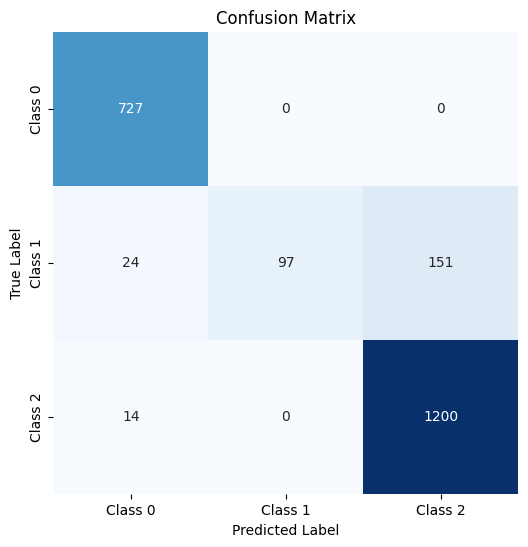

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(cm)

# Plotting Confusion Matrix
def plot_confusion_matrix(cm):
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Class 0","Class 1", "Class 2"], yticklabels=["Class 0","Class 1", "Class 2"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Call the evaluate_model function to evaluate the model
evaluate_model(model, val_dataloader, device)


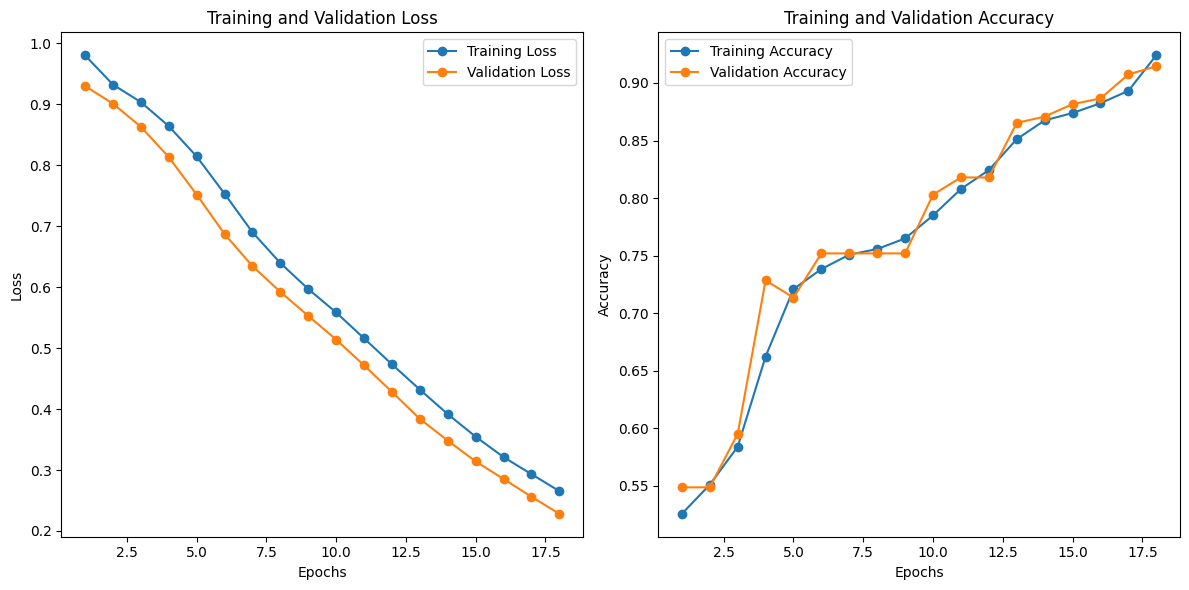

In [ ]:
import matplotlib.pyplot as plt

# Data for 18 epochs
epochs = list(range(1, 19))

train_loss = [
    0.9807, 0.9326, 0.9039, 0.8644, 0.8147, 0.7535, 0.6903, 0.6397, 0.5971,
    0.5586, 0.5161, 0.4735, 0.4320, 0.3917, 0.3547, 0.3212, 0.2932, 0.2654
]
val_loss = [
    0.9303, 0.9013, 0.8634, 0.8136, 0.7521, 0.6874, 0.6347, 0.5924, 0.5531,
    0.5140, 0.4718, 0.4282, 0.3839, 0.3483, 0.3141, 0.2853, 0.2561, 0.2282
]

train_accuracy = [
    0.5256, 0.5509, 0.5839, 0.6623, 0.7209, 0.7383, 0.7508, 0.7557, 0.7649,
    0.7849, 0.8079, 0.8243, 0.8512, 0.8675, 0.8739, 0.8824, 0.8932, 0.9241
]
val_accuracy = [
    0.5486, 0.5486, 0.5951, 0.7284, 0.7135, 0.7519, 0.7519, 0.7519, 0.7519,
    0.8030, 0.8179, 0.8179, 0.8653, 0.8708, 0.8816, 0.8866, 0.9074, 0.9146
]



plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()
